# Lab 6 Machein Learning
# Name- Daksh khandelwal
# Roll no- 45
# Batch- B_B3

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_csv("seeds_new.csv")

In [ ]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)",Unnamed: 8,Unnamed: 9
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,NaN,NaN
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,NaN,NaN
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,NaN,NaN
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,NaN,NaN
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,NaN,NaN


In [ ]:
df.tail()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)",Unnamed: 8,Unnamed: 9
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3,NaN,NaN
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3,NaN,NaN
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3,NaN,NaN
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3,NaN,NaN
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3,NaN,NaN


In [ ]:
print(df.shape)

(210, 10)


In [ ]:
df.columns

Index(['Area', 'Perimeter', 'Compactness', 'Length of kernel',
       'Width of kernel', 'Asymmetry coefficient', 'Length of kernel groove',
       'Class (1, 2, 3)', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length of kernel         210 non-null    float64
 4   Width of kernel          210 non-null    float64
 5   Asymmetry coefficient    210 non-null    float64
 6   Length of kernel groove  210 non-null    float64
 7   Class (1, 2, 3)          210 non-null    int64  
 8   Unnamed: 8               2 non-null      object 
 9   Unnamed: 9               1 non-null      object 
dtypes: float64(7), int64(1), object(2)
memory usage: 16.5+ KB


In [ ]:
df.describe()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
Perimeter,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
Compactness,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
Length of kernel,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
Width of kernel,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
Asymmetry coefficient,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
Length of kernel groove,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500
"Class (1, 2, 3)",210.0,2.000000,0.818448,1.0000,1.00000,2.00000,3.000000,3.0000


In [ ]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Length of kernel,0
Width of kernel,0
Asymmetry coefficient,0
Length of kernel groove,0
"Class (1, 2, 3)",0
Unnamed: 8,208
Unnamed: 9,209


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input ,Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
X=df.drop("Class (1, 2, 3)", axis=1)
y_original=df["Class (1, 2, 3)"]

print("Input Shape",X.shape)
print("Output Shape",y_original.shape)

Input Shape (210, 9)
Output Shape (210,)


In [ ]:
y=y_original - 1
print("Original Classes:")
print(sorted(y_original.unique()))

print("\nANN Encloded Classes:")
print(sorted(y.unique()))

Original Classes:
[np.int64(1), np.int64(2), np.int64(3)]

ANN Encloded Classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training Sample",X_train.shape[0])
print("Testing Sample",X_test.shape)

Training Sample 168
Testing Sample (42, 9)


In [ ]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)",Unnamed: 8,Unnamed: 9
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,NaN,NaN
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,NaN,NaN
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,NaN,NaN
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,NaN,NaN
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,NaN,NaN


In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

ValueError: could not convert string to float: ' '

In [ ]:
model = Sequential()
model.add(Input(shape=(7,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
loss="sparse_categorial_crossentropy"


In [ ]:
early_stop=EarlyStopping(monitor="val_loss",patience=25,restore_best_weights=True)

In [ ]:
history=model.fit(
    X_train_scaled,y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop], verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.2612 - loss: 1.1208 - val_accuracy: 0.1176 - val_loss: 1.1398
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2687 - loss: 1.0706 - val_accuracy: 0.1765 - val_loss: 1.0842
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3433 - loss: 1.0278 - val_accuracy: 0.3235 - val_loss: 1.0357
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5075 - loss: 0.9899 - val_accuracy: 0.5588 - val_loss: 0.9872
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5896 - loss: 0.9524 - val_accuracy: 0.6471 - val_loss: 0.9458
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6642 - loss: 0.9159 - val_accuracy: 0.7059 - val_loss: 0.9041
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7164 - loss: 0.8781 - val_accuracy: 0.7647 - val_loss: 0.8604
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7836 - loss: 0.8380 - val_accuracy: 0.7941 - val_loss:

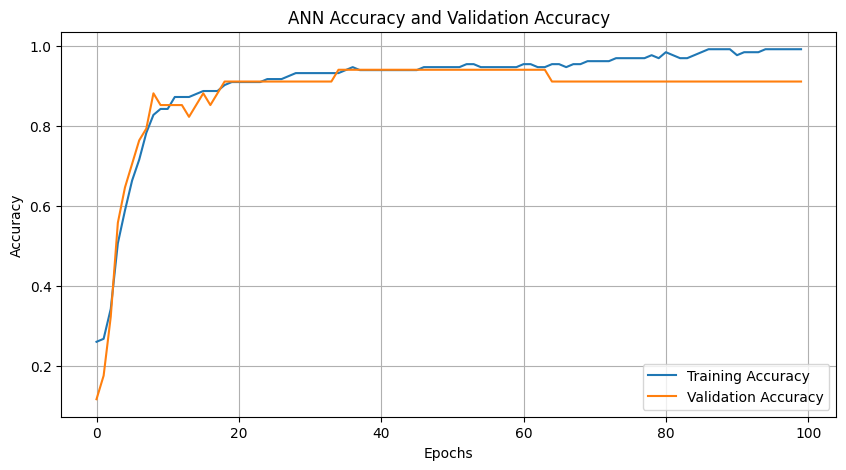

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Accuracy and Validation Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

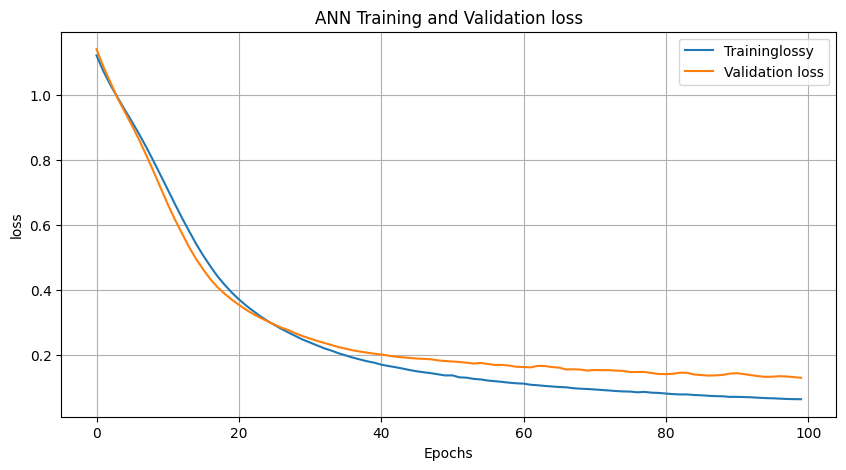

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Traininglossy')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title("ANN Training and Validation loss")
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_loss,test_accuracy=model.evaluate(X_test_scaled,y_test,verbose=1)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8333 - loss: 0.3856
Test Loss: 0.3856332302093506
Test Accuracy: 0.8333333134651184


In [ ]:
y_prob=model.predict(X_test_scaled,verbose=1)
print(y_prob[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
[[9.9597466e-01 5.3777522e-04 3.4875514e-03]
 [6.1605416e-02 2.6118796e-04 9.3813342e-01]
 [7.8409594e-01 2.1310619e-01 2.7978844e-03]
 [5.8096991e-04 2.6725263e-06 9.9941629e-01]
 [4.5215045e-04 9.9954766e-01 9.4685127e-08]]


In [ ]:
y_pred=np.argmax(y_prob,axis=1)
print("Predicted Enclosed Class")
print(y_pred[:10])

Predicted Enclosed Class
[0 2 0 2 1 2 1 1 1 1]


In [ ]:
y_pred_orignal=y_pred +1
y_test_orignal=y_test +1
print("Original Classes")
print(y_test_orignal[:10])
print("Pridicted Classes")
print(y_pred_orignal[:10])

Original Classes
2      1
167    3
137    2
175    3
130    2
141    3
114    2
51     1
84     2
110    2
Name: Class (1, 2, 3), dtype: int64
Pridicted Classes
[1 3 1 3 2 3 2 2 2 2]


In [ ]:
comparison=pd.DataFrame({"Actual Class":y_test_orignal,"Predicted Class":y_pred_orignal})
print(comparison.head(15))

     Actual Class  Predicted Class
2               1                1
167             3                3
137             2                1
175             3                3
130             2                2
141             3                3
114             2                2
51              1                2
84              2                2
110             2                2
23              1                3
182             3                3
129             2                2
131             2                2
171             3                3


In [ ]:
accuracy= accuracy_score(y_test_orignal,y_pred_orignal)
print("Accuracy:",accuracy)

Accuracy: 0.8333333333333334


In [ ]:
precision_score=precision_score(y_test_orignal,y_pred_orignal,average="weighted")
print("Precision:",precision_score)


Precision: 0.8416394335511983


In [ ]:
recall=recall_score(y_test_orignal,y_pred_orignal,average="weighted")
print("Recall:",recall)

Recall: 0.8333333333333334


In [ ]:
f1=f1_score(y_test_orignal,y_pred_orignal,average="weighted")
print("F1 Score:",f1)

F1 Score: 0.8218482156771078


In [ ]:
metrics=pd.DataFrame({
    "Accuracy":[accuracy],
    "Precision":[precision_score],
    "Recall":[recall],
    "F1 Score":[f1]
})
print(metrics)

   Accuracy  Precision    Recall  F1 Score
0  0.833333   0.841639  0.833333  0.821848


In [ ]:
print(classification_report(y_test_orignal,y_pred_orignal))


              precision    recall  f1-score   support

           1       0.89      0.57      0.70        14
           2       0.81      0.93      0.87        14
           3       0.82      1.00      0.90        14

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.82        42
weighted avg       0.84      0.83      0.82        42



In [ ]:
cm=confusion_matrix(y_test_orignal,y_pred_orignal)
print(cm)

[[ 8  3  3]
 [ 1 13  0]
 [ 0  0 14]]


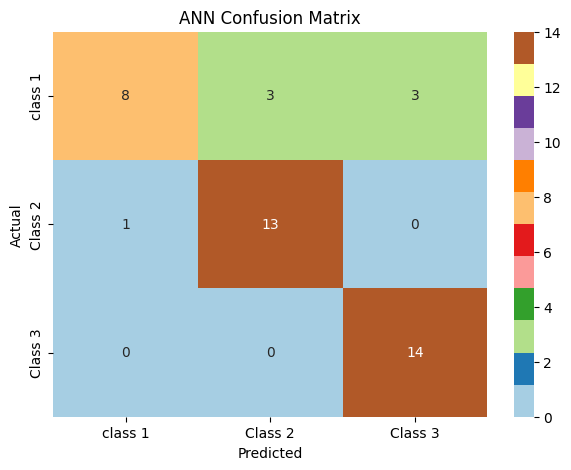

In [ ]:

plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Paired', xticklabels=["class 1","Class 2", "Class 3"], yticklabels=["class 1","Class 2", "Class 3"])
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

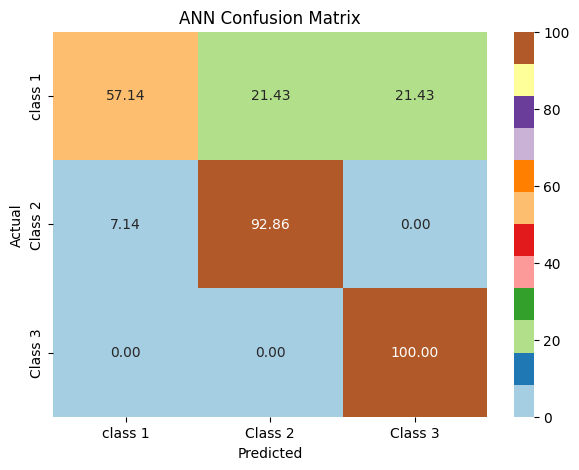

In [ ]:
cm_percentage = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] *100

plt.figure(figsize=(7,5))

sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Paired', xticklabels=["class 1","Class 2", "Class 3"], yticklabels=["class 1","Class 2", "Class 3"])
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
area=float(input["Enter Area:"])
perimeter=float(input["Enter Perimeter:"])
compactness=float(input["Enter Compactness:"])
length=float(input["Enter Length:"])
width=float(input["Enter Width:"])
asymmetry=float(input["Enter Asymmetry:"])
groove_length=float(input["Enter Groove Length:"])
predict_new_seed

In [ ]:
area=float(input("Enter Area:"))
perimeter=float(input("Enter Perimeter:"))
compactness=float(input("Enter Compactness:"))
length=float(input("Enter Length:"))
width=float(input("Enter Width:"))
asymmetry=float(input("Enter Asymmetry:"))
groove_length=float(input("Enter Groove Length:"))

Enter Area:15
Enter Perimeter:20
Enter Compactness:30
Enter Length:40
Enter Width:54
Enter Asymmetry:50
Enter Groove Length:27
